# Final Project

## Question: Does cross-platform social media usage increase the spread of English words in German social media networks?

In [63]:
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from collections import deque

import networkx as nx

# Simulating a simple agent

Each agent has the following attributes:
* age_group: GenZ, Millenial, Boomer. Different age groups behave differently on the Internet.
* english_proficiency: Between 1 and 3. 1: Low, 2: Medium, 3: High. Describes how well the user speaks and understands English.
* topic: Gaming, Tech, Fashion, Nature. The preferred topic of the user.
* platforms: Instagram, TikTok, Reddit. The list of platforms used. A user can have one platform or use multiple platforms (cross-platform)

In [64]:
age_groups: list[str] = ["GenZ", "Millenial", "Boomer"]
topics: list[str] = ["Gaming", "Tech", "Fashion", "Nature"]
platforms: list[str] = ["Instagram", "TikTok", "Reddit"]

In [65]:
class PlayerAgent(mesa.Agent):
    def __init__(self, model:mesa.Model):
        super().__init__(model)

        self.age_group: str = self.get_random_age_group()
        self.english_proficiency: int = self.get_random_english_proficiency()
        self.main_topic: str = self.get_random_main_topic()
        self.platforms: list[str] = self.get_random_platforms()

        self.adopted = False # Whether the user adopted the english word or not
        self.is_influencer = False #user is an influencer or not

    def get_random_age_group(self) -> int:
        return random.choice(age_groups)

    def get_random_english_proficiency(self) -> int:
        return random.randint(1, 3)

    def get_random_main_topic(self) -> str:
        return random.choice(topics)

    def get_random_platforms(self) -> list[str]:
        random_platforms: list[str] = []

        for platform in platforms:
            if random.random() < 0.33:
                random_platforms.append(platform)

        # If player still has no platform, force a random one
        if len(random_platforms) == 0:
            random_platforms.append(random.choice(platforms))
        
        return random_platforms

    def print_description(self):
        """Prints the descirption of the player"""
        print(f'Player {self.unique_id} :')
        print(f'Age Group : {self.age_group}')
        print(f'English proficiency : {self.english_proficiency}')
        print(f'Main topic : {self.main_topic}')
        print("Platforms : ", end="")
        for i in range(len(self.platforms)):
            if i != 0:
                print(", ", end="")
            print(self.platforms[i], end="")

In [66]:
class SimpleGame(mesa.Model):
    def __init__(self, players_count: int):
        super().__init__()

        self.players_count: int = players_count
        self.player: PlayerAgent = PlayerAgent(self)

In [67]:
game: SimpleGame = SimpleGame(1)
game.player.print_description()

Player 1 :
Age Group : Boomer
English proficiency : 1
Main topic : Gaming
Platforms : Instagram, Reddit

# Creating Networks of social media users

In [87]:
class Network(mesa.Model):
    def __init__(self, rounds_count: int, players_count: int, inital_adopters: int, influencer_mode: bool = False):
        super().__init__()

        self.network = nx.Graph()
        self.rounds_count: int = rounds_count
        self.players_count: int = players_count
        self.players: list[PlayerAgent] = []
        self.adopted_players : list[PlayerAgent] = []

        self.connect_crossplatform_threshold: float = 0.01
        self.influencer_connection_threshold: float = 0.10
        
        self.initial_adopters_count: int = inital_adopters
        self.influencer_mode = influencer_mode

        self.create_players()
        self.pick_initial_adopters()
        self.connect_cross_platform_users()

        self.datacollector = mesa.DataCollector(
            {
                "Adoption Rate" : self.adoption_rate,
                "Instagram Adoption Rate": self.adoption_rate_instagram,
                "TikTok Adoption Rate": self.adoption_rate_tiktok,
                "Reddit Adoption Rate": self.adoption_rate_reddit
            }
        )

    def create_players(self):
        """Creates all player agents and connects them in a network of social media users."""
        for _ in range(self.players_count):
            new_player: PlayerAgent = PlayerAgent(self)
            self.players.append(new_player)
            self.network.add_node(new_player)

    def connect_cross_platform_users(self):
        """Tries to connect users between each other if they share common platforms."""

        already_checked = set()

        for player1 in self.players:
            for player2 in self.players:
                if player1 == player2: # Can't connect same player
                    continue

                #check if pair was already checked
                pair = frozenset([player1.unique_id, player2.unique_id])
                if pair in already_checked:
                    continue
                already_checked.add(pair)

                # Get the set of shared platforms between 2 agents
                shared_platforms: set[str] = set(player1.platforms) & set(player2.platforms)

                # Try to randomly connect agents with eachother if they have shared platforms
                connection_probability = self.connect_crossplatform_threshold

                #if either player is an influencer chance to connect is higher (10% instead of 1%)
                if player1.is_influencer or player2.is_influencer:
                    connection_probability = self.influencer_connection_threshold

                if len(shared_platforms) > 0 and random.random() < connection_probability:
                    self.network.add_edge(player1, player2)

    def pick_initial_adopters(self):
        """Pick a few inital adopters that already know English words. Behave as influencers to influence other users to also use their words."""

        #initial adopter is 1 influencer, ignores initial_adopters
        if self.influencer_mode:
            influencer = random.choice(self.players)
            influencer.platforms = ["Instagram", "TikTok", "Reddit"]
            influencer.adopted = True
            influencer.is_influencer = True
            self.adopted_players.append(influencer)

        else:
            initial_adopters: list[PlayerAgent] = random.sample(self.players, self.initial_adopters_count)
            for player in initial_adopters:
                player.adopted = True
                self.adopted_players.append(player)

    def play_game(self):
        self.datacollector.collect(self) #get initial state
        for i in range(self.rounds_count):
            #print(f'Round {i + 1} :')
            self.play_round()
            #print(f'Got adoption rate: {round(self.adoption_rate() * 100, 2)} %')
            self.datacollector.collect(self)

    def play_round(self):
        new_adopted_players: list[PlayerAgent] = []

        for player in self.players:
            neighbors: list[PlayerAgent] = list(self.network.neighbors(player))

            # Count the number of adopted neighbors
            adopted_neighbors: int = 0
            for neighbor in neighbors:
                if neighbor.adopted:
                    adopted_neighbors += 1

            if adopted_neighbors == 0:
                continue
            
            # Compute adoption probability based on agent properties
            adoption_probability: float = 0.001

            if len(neighbors) > 0:
                adopted_fraction: float = adopted_neighbors / len(neighbors)
                adoption_probability += 0.10 * adopted_fraction

            adoption_probability += 0.001 * player.english_proficiency
            
            if player.age_group == "GenZ":
                adoption_probability += 0.01
            elif player.age_group == "Millenial":
                adoption_probability += 0.005

            if adoption_probability >= 1:
                adoption_probability = 1
            
            if not player.adopted:
                if random.random() < adoption_probability:
                    #print(f'Agent {player.unique_id} adopted the English word ! (P = {round(adoption_probability * 100, 2)} %)')
                    new_adopted_players.append(player)
                else:
                    #print(f'Agent {player.unique_id} did not adopt the english word ! (P = {round(adoption_probability * 100, 2)} %)')
                    continue

        for adopted_player in new_adopted_players:
            adopted_player.adopted = True
            self.adopted_players.append(adopted_player)
    
    def adoption_rate(self) -> float:
        """Function for data collection. Returns the proportion of adopted players in the network."""
        return len(self.adopted_players) / self.players_count
    
    def adoption_rate_instagram(self) -> float:
        instagram_players = []
        for player in self.players:
            if "Instagram" in player.platforms:
                instagram_players.append(player)

        if len(instagram_players) == 0:
            return 0

        adopted_instagram_players = []
        for player in instagram_players:
            if player.adopted:
                adopted_instagram_players.append(player)

        return len(adopted_instagram_players) / len(instagram_players)
    
    def adoption_rate_tiktok(self) -> float:
        tiktok_players = []
        for player in self.players:
            if "TikTok" in player.platforms:
                tiktok_players.append(player)

        if len(tiktok_players) == 0:
            return 0

        adopted_tiktok_players = []
        for player in tiktok_players:
            if player.adopted:
                adopted_tiktok_players.append(player)

        return len(adopted_tiktok_players) / len(tiktok_players)

    def adoption_rate_reddit(self) -> float:
        reddit_players = []
        for player in self.players:
            if "Reddit" in player.platforms:
                reddit_players.append(player)

        if len(reddit_players) == 0:
            return 0

        adopted_reddit_players = []
        for player in reddit_players:
            if player.adopted:
                adopted_reddit_players.append(player)

        return len(adopted_reddit_players) / len(reddit_players)       


In [69]:
def plot_adoption_rate(data: pd.DataFrame):
    adoption_rate = data["Adoption Rate"]
    rounds = np.arange(0, len(adoption_rate))

    plt.plot(rounds, adoption_rate * 100)
    plt.title("Evolution of adoption rate over rounds")
    plt.xlabel("Rounds")
    plt.ylabel("Adoption rate (%)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

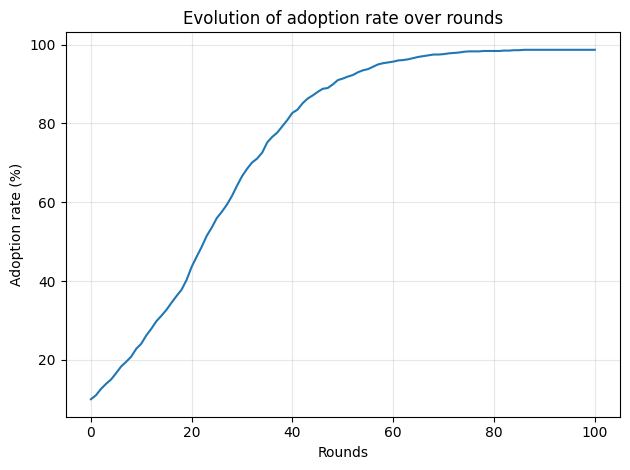

In [70]:
network = Network(rounds_count=100, players_count=1000, inital_adopters=100)
network.play_game()

data = network.datacollector.get_model_vars_dataframe()
plot_adoption_rate(data)

# Adoption rate over time with different numbers of initial adopters

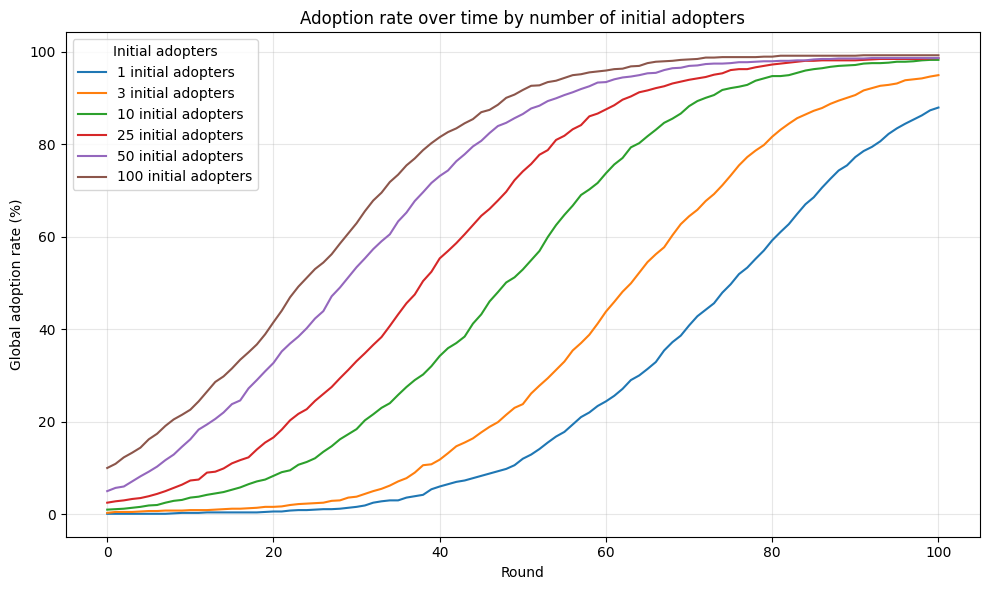

In [71]:
initial_adopters_list = [1, 3, 10, 25, 50, 100]

all_data = []

for initial_adopters in initial_adopters_list:
    network = Network(
        rounds_count=100,
        players_count=1000,
        inital_adopters=initial_adopters
    )

    network.play_game()

    data = network.datacollector.get_model_vars_dataframe()
    data["Round"] = np.arange(0, len(data))
    data["Initial Adopters"] = initial_adopters

    all_data.append(data)

results_df = pd.concat(all_data, ignore_index=True)

plt.figure(figsize=(10, 6))

for initial_adopters in initial_adopters_list:
    subset = results_df[results_df["Initial Adopters"] == initial_adopters]

    plt.plot(
        subset["Round"],
        subset["Adoption Rate"] * 100,
        label=f"{initial_adopters} initial adopters"
    )

plt.title("Adoption rate over time by number of initial adopters")
plt.xlabel("Round")
plt.ylabel("Global adoption rate (%)")
plt.legend(title="Initial adopters")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Adoption rate over time by platform with 1 initial adopter

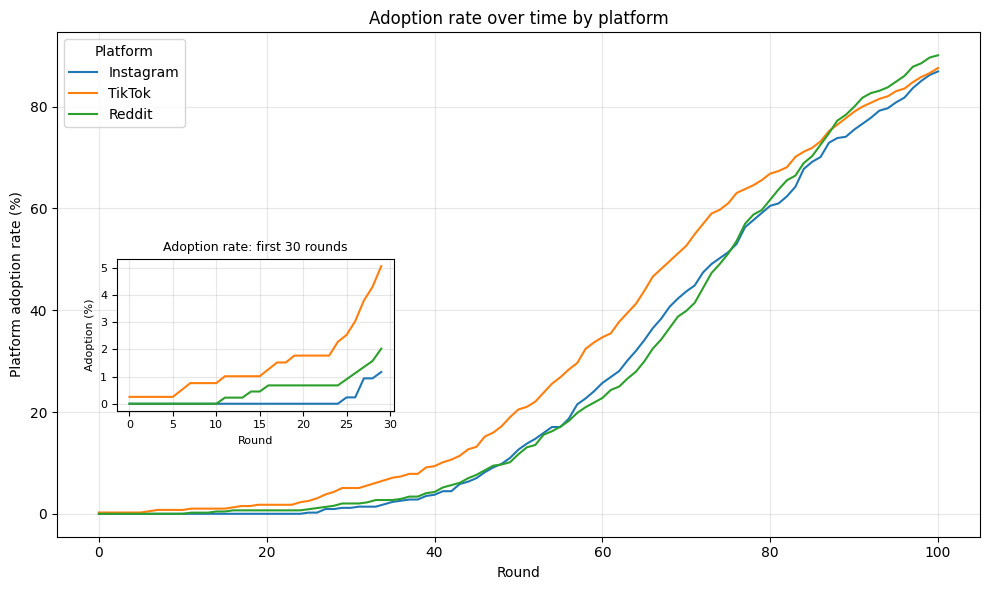

In [81]:
def plot_platform_adoption_rates(data: pd.DataFrame, influencer: bool = False):
    rounds = range(0, len(data))

    #use subplot to show first rounds more clearly inside main plot
    figure, axis = plt.subplots(figsize=(10, 6))

    axis.plot(rounds, data["Instagram Adoption Rate"] * 100, label="Instagram")
    axis.plot(rounds, data["TikTok Adoption Rate"] * 100, label="TikTok")
    axis.plot(rounds, data["Reddit Adoption Rate"] * 100, label="Reddit")

    axis.set_title("Adoption rate over time by platform")
    axis.set_xlabel("Round")
    axis.set_ylabel("Platform adoption rate (%)")
    axis.legend(title="Platform")
    axis.grid(True, alpha=0.3)

    if not influencer:
        #position + size of inset
        inset_axis = axis.inset_axes([0.065, 0.25, 0.30, 0.30])

        first_30_rounds_data = data.iloc[:30]
        inset_rounds = np.arange(0, len(first_30_rounds_data))

        inset_axis.plot(inset_rounds, first_30_rounds_data["Instagram Adoption Rate"] * 100)
        inset_axis.plot(inset_rounds, first_30_rounds_data["TikTok Adoption Rate"] * 100)
        inset_axis.plot(inset_rounds, first_30_rounds_data["Reddit Adoption Rate"] * 100)

        inset_axis.set_title("Adoption rate: first 30 rounds", fontsize=9)
        inset_axis.set_xlabel("Round", fontsize=8)
        inset_axis.set_ylabel("Adoption (%)", fontsize=8)
        inset_axis.tick_params(axis="both", labelsize=8)
        inset_axis.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

network = Network(rounds_count=100, players_count=1000, inital_adopters=1)
network.play_game()

data = network.datacollector.get_model_vars_dataframe()
plot_platform_adoption_rates(data)

# Adoption rate over time by platform with 1 influencer as initial adopter

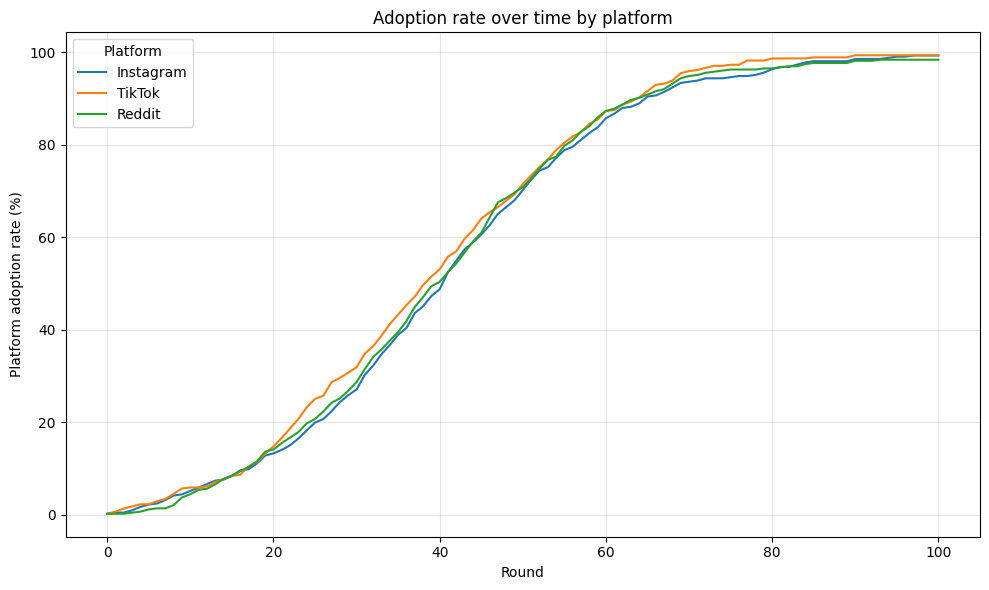

In [89]:
network = Network(rounds_count=100, players_count=1000, inital_adopters=1, influencer_mode=True)
network.play_game()

data = network.datacollector.get_model_vars_dataframe()
plot_platform_adoption_rates(data, influencer=True)